# Temporary notebook - Density vs coverage intuition

This temporary notebook creates synthetic figures to inspect the difference between density-oriented evaluation and coverage-oriented evaluation. It is intended to help prepare images and wording for the research diary, then be deleted later.

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity
from sklearn.metrics import pairwise_distances

sns.set_theme(style='whitegrid', context='talk')
ROOT = Path.cwd()
OUTDIR = ROOT / 'notebooks' / 'data' / 'tmp_density_vs_coverage'
OUTDIR.mkdir(parents=True, exist_ok=True)
SEED = 42
rng = np.random.default_rng(SEED)


## 1. Synthetic moons with non-uniform density

We build a two-moons dataset, then intentionally increase density in one local region so that empirical sampling does not match geometric coverage.

In [2]:
def _sample_parametric_moons(n_upper=900, n_lower=900, noise=0.05, seed=SEED):
    rng = np.random.default_rng(seed)

    # Upper moon: nearly uniform angular density.
    t_upper = rng.uniform(0.0, np.pi, size=n_upper)
    upper = np.column_stack([np.cos(t_upper), np.sin(t_upper)])

    # Lower moon: same geometric support, but non-uniform density concentrated on the right arm.
    mix = rng.uniform(size=n_lower)
    t_lower = np.empty(n_lower)
    dense_mask = mix < 0.7
    sparse_mask = ~dense_mask
    t_lower[dense_mask] = np.pi * rng.beta(8.0, 2.0, size=dense_mask.sum())
    t_lower[sparse_mask] = rng.uniform(0.0, np.pi, size=sparse_mask.sum())
    lower = np.column_stack([1.0 - np.cos(t_lower), 0.5 - np.sin(t_lower)])

    x = np.vstack([upper, lower])
    y = np.concatenate([
        np.zeros(n_upper, dtype=np.int64),
        np.ones(n_lower, dtype=np.int64),
    ])
    x = x + rng.normal(scale=noise, size=x.shape)
    return x.astype(np.float64), y.astype(np.int64)


x_imbalanced, y_imbalanced = _sample_parametric_moons(n_upper=900, n_lower=1500, noise=0.055, seed=SEED)

print({'n_total': int(len(x_imbalanced)), 'class_counts': {int(k): int(v) for k, v in zip(*np.unique(y_imbalanced, return_counts=True))}})


{'n_total': 2400, 'class_counts': {0: 900, 1: 1500}}


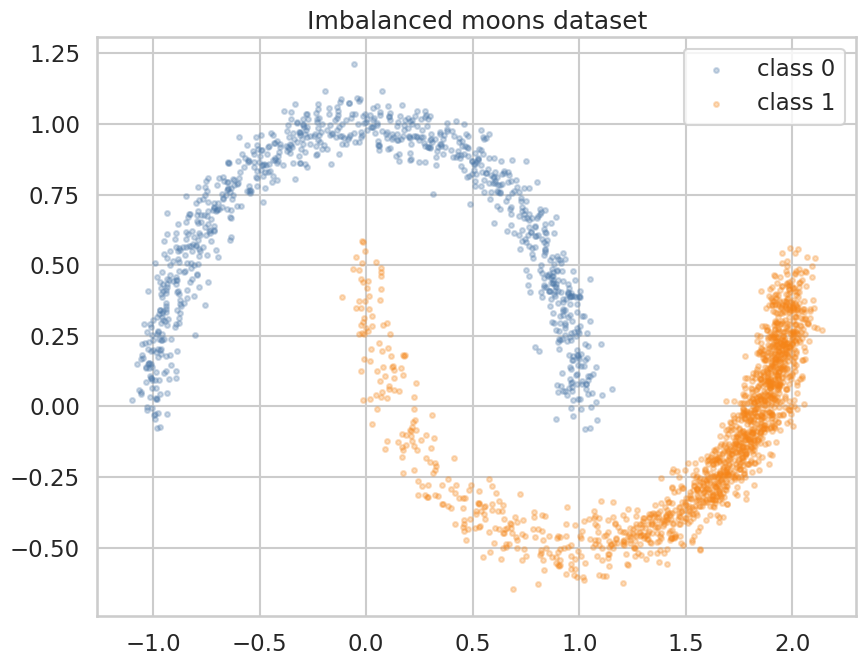

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/notebooks/data/tmp_density_vs_coverage/01_imbalanced_moons.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 7))
for label, color in [(0, '#4C78A8'), (1, '#F58518')]:
    pts = x_imbalanced[y_imbalanced == label]
    ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.28, c=color, label=f'class {label}')
ax.set_title('Imbalanced moons dataset')
ax.legend(frameon=True)
plt.tight_layout()
fig_path = OUTDIR / '01_imbalanced_moons.png'
fig.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(fig_path)


## 2. Two prototype-selection philosophies on the target class

We compare:
- density-oriented prototypes: k-means centers approximated by nearest target-class points
- coverage-oriented prototypes: anchors chosen at uniform positions of a geometric arc parameter, independently of empirical density

In [4]:
target_label = 1
x_target = x_imbalanced[y_imbalanced == target_label]

k = 12

# Density-oriented: k-means then snap to nearest real target points.
kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=20)
kmeans.fit(x_target)
centers = kmeans.cluster_centers_
nearest = pairwise_distances(centers, x_target).argmin(axis=1)
proto_density = x_target[nearest]

# Coverage-oriented: choose anchors at uniform positions of the lower-moon geometric parameter.
geom_t = np.arctan2(-(x_target[:, 1] - 0.5), -(x_target[:, 0] - 1.0))
geom_t = np.mod(geom_t, 2 * np.pi)
geom_t = np.where(geom_t > np.pi, 2 * np.pi - geom_t, geom_t)
geom_centers = np.linspace(0.0, np.pi, k)
chosen = []
for center_t in geom_centers:
    idx = int(np.argmin(np.abs(geom_t - center_t)))
    chosen.append(idx)
proto_coverage = x_target[np.unique(chosen)]

print({'k': k, 'density_prototypes': proto_density.shape[0], 'coverage_prototypes': proto_coverage.shape[0]})


{'k': 12, 'density_prototypes': 12, 'coverage_prototypes': 12}


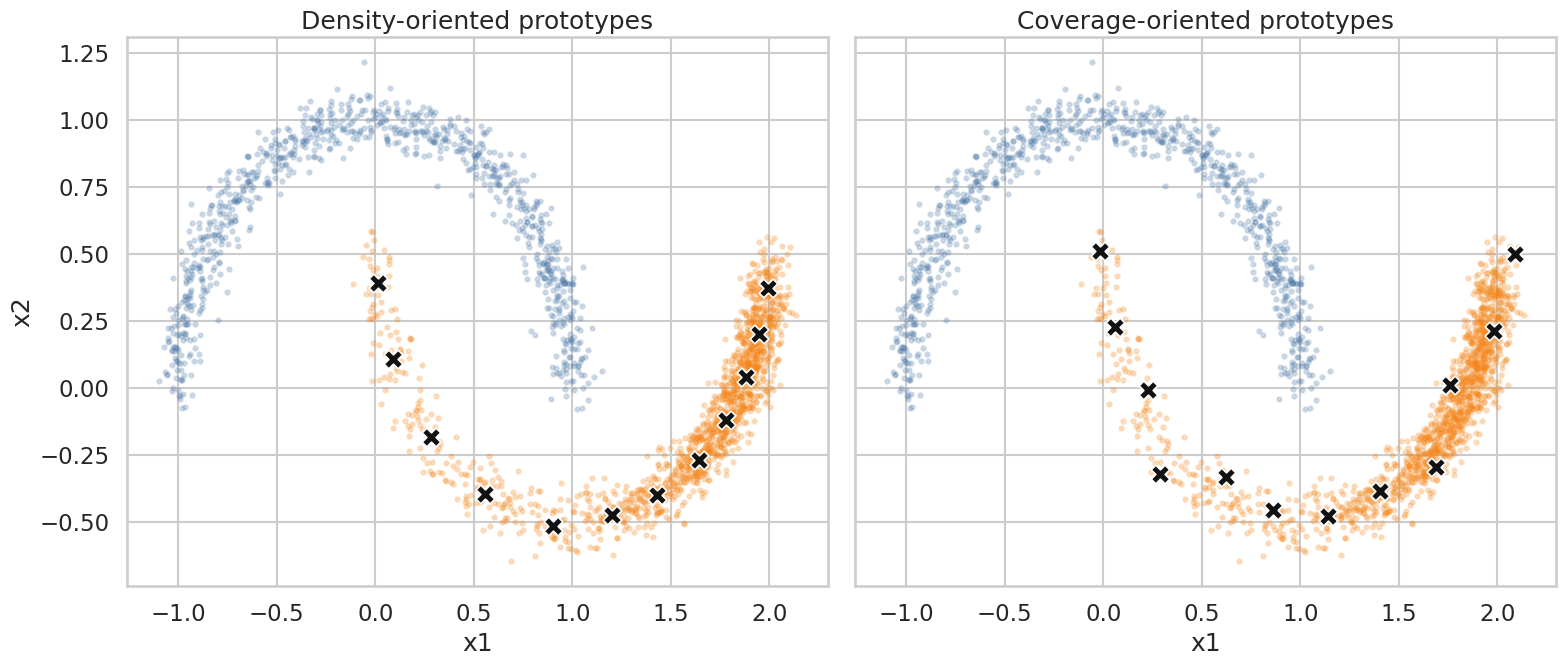

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/notebooks/data/tmp_density_vs_coverage/02_prototype_philosophies.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
for ax, title, protos in [
    (axes[0], 'Density-oriented prototypes', proto_density),
    (axes[1], 'Coverage-oriented prototypes', proto_coverage),
]:
    for label, color in [(0, '#4C78A8'), (1, '#F58518')]:
        pts = x_imbalanced[y_imbalanced == label]
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.22, c=color)
    ax.scatter(protos[:, 0], protos[:, 1], s=180, marker='X', c='#111111', linewidths=1.2, edgecolors='white')
    ax.set_title(title)
    ax.set_xlabel('x1')
axes[0].set_ylabel('x2')
plt.tight_layout()
fig_path = OUTDIR / '02_prototype_philosophies.png'
fig.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(fig_path)


## 3. Evaluation points: empirical density vs balanced geometric support

We construct two evaluation sets on the target class:
- density-weighted: random sample from the target-class data
- balanced-coverage: one equal sample from each uniform bin of a geometric arc parameter along the moon

In [6]:
n_eval = 240

# Density-weighted evaluation from empirical data.
density_eval_idx = rng.choice(len(x_target), size=n_eval, replace=False)
x_eval_density = x_target[density_eval_idx]

# Balanced evaluation from uniform bins of the geometric parameter.
geom_edges = np.linspace(0.0, np.pi, 25)
per_bin = max(1, n_eval // (len(geom_edges) - 1))
coverage_eval = []
for lo, hi in zip(geom_edges[:-1], geom_edges[1:]):
    mask = (geom_t >= lo) & (geom_t < (hi if hi < np.pi else hi + 1e-9))
    inds = np.where(mask)[0]
    if len(inds) == 0:
        continue
    take = min(per_bin, len(inds))
    picked = rng.choice(inds, size=take, replace=False)
    coverage_eval.append(x_target[picked])
x_eval_balanced = np.vstack(coverage_eval)

print({'density_eval': len(x_eval_density), 'balanced_eval': len(x_eval_balanced)})


{'density_eval': 240, 'balanced_eval': 240}


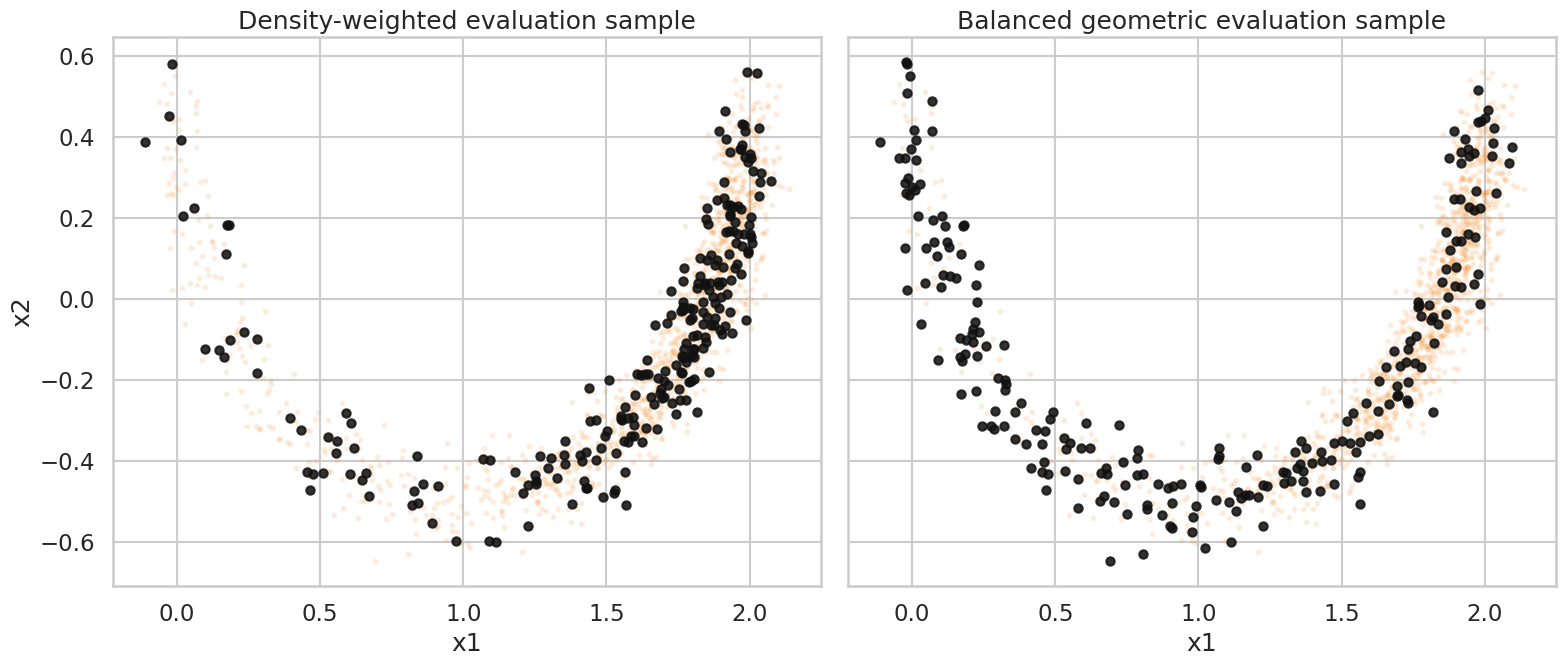

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/notebooks/data/tmp_density_vs_coverage/03_evaluation_sets.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
views = [
    ('Density-weighted evaluation sample', x_eval_density),
    ('Balanced geometric evaluation sample', x_eval_balanced),
]
for ax, (title, eval_pts) in zip(axes, views):
    ax.scatter(x_target[:, 0], x_target[:, 1], s=8, alpha=0.10, c='#F58518')
    ax.scatter(eval_pts[:, 0], eval_pts[:, 1], s=36, alpha=0.85, c='#111111')
    ax.set_title(title)
    ax.set_xlabel('x1')
axes[0].set_ylabel('x2')
plt.tight_layout()
fig_path = OUTDIR / '03_evaluation_sets.png'
fig.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(fig_path)


## 4. Simple coverage proxy under the two evaluation regimes

As a toy proxy, we measure whether an evaluation point falls within a fixed-radius neighborhood of at least one prototype. This is not a CertCF polytope computation; it is only a geometric illustration of the density-vs-coverage issue.

In [ ]:
radius = 0.14

def coverage_rate(eval_pts, protos, radius):
    d = pairwise_distances(eval_pts, protos)
    covered = (d <= radius).any(axis=1)
    return float(covered.mean())

summary = pd.DataFrame([
    {
        'evaluation': 'density_weighted',
        'prototypes': 'density_oriented',
        'coverage_rate': coverage_rate(x_eval_density, proto_density, radius),
    },
    {
        'evaluation': 'density_weighted',
        'prototypes': 'coverage_oriented',
        'coverage_rate': coverage_rate(x_eval_density, proto_coverage, radius),
    },
    {
        'evaluation': 'balanced_geometric',
        'prototypes': 'density_oriented',
        'coverage_rate': coverage_rate(x_eval_balanced, proto_density, radius),
    },
    {
        'evaluation': 'balanced_geometric',
        'prototypes': 'coverage_oriented',
        'coverage_rate': coverage_rate(x_eval_balanced, proto_coverage, radius),
    },
])
summary


,evaluation,prototypes,coverage_rate
0,density_weighted,density_oriented,0.929167
1,density_weighted,coverage_oriented,0.779167
2,balanced_geometric,density_oriented,0.854167
3,balanced_geometric,coverage_oriented,0.766667


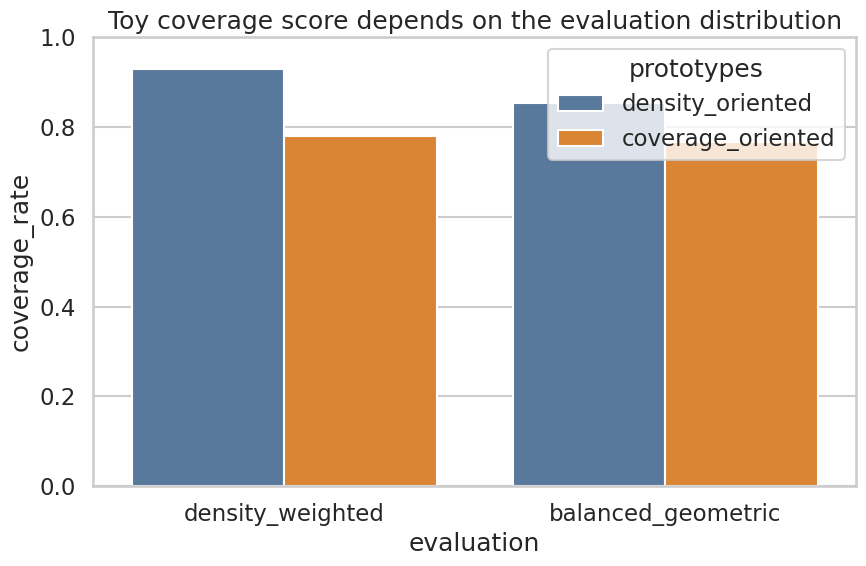

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/notebooks/data/tmp_density_vs_coverage/04_toy_coverage_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=summary, x='evaluation', y='coverage_rate', hue='prototypes', palette=['#4C78A8', '#F58518'], ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Toy coverage score depends on the evaluation distribution')
plt.tight_layout()
fig_path = OUTDIR / '04_toy_coverage_comparison.png'
fig.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(fig_path)


## 5. Optional figure export summary

These paths can be reused later if we decide to move selected images into the Obsidian vault.

In [10]:
exported = sorted(str(p) for p in OUTDIR.glob('*.png'))
pd.DataFrame({'image_path': exported})


,image_path
0,/home/gabrielepintus/Documents/github/Preimage...
1,/home/gabrielepintus/Documents/github/Preimage...
2,/home/gabrielepintus/Documents/github/Preimage...
3,/home/gabrielepintus/Documents/github/Preimage...
